<h1> Hands on: TDDFT with <span style="color: red;">QE</span>py</h1>

#### Obtain the Absorption Spectra of Molecules with turbo davidson



## To run this tutorial we need to
 - import QEpy
 - Use ASE to generate molecular structures

In [1]:
import qepy
from qepy.driver import Driver
from qepy.io import QEInput
from ase.build import molecule
import numpy as np
import matplotlib.pyplot as plt

## Download some pseudopotentials

In [2]:
additional_files = {
    'H.pz-vbc.UPF' : 'https://pseudopotentials.quantum-espresso.org/upf_files/H.pz-vbc.UPF',
    'C.pz-vbc.UPF' : 'https://pseudopotentials.quantum-espresso.org/upf_files/C.pz-vbc.UPF',
}
from dftpy.formats import download_files
download_files(additional_files)

## Generate the QE options to run a scf calculation

In [3]:
prefix = 'c2h4'

In [4]:
scf_options = {}

scf_options['&control'] = {}
scf_options['&control']['calculation'] = 'scf'
scf_options['&control']['prefix'] = prefix
scf_options['&control']['restart_mode'] = 'from_scratch'
scf_options['&control']['outdir'] = 'tmp'
scf_options['&control']['pseudo_dir'] = './'

scf_options['&system'] = {}
scf_options['&system']['ecutwfc'] = 25

scf_options['&electrons'] = {}
scf_options['&electrons']['conv_thr'] = 1.0E-10

scf_options['atomic_species'] = []
scf_options['atomic_species'].append('H  1.008  H.pz-vbc.UPF')
scf_options['atomic_species'].append('C 12.011  C.pz-vbc.UPF')

scf_options['k_points {gamma}'] = []

## Workflow for SCF

 1. Use ASE to build a new molecule
 2. Set periodic cell
 3. Update  QEpy options dictionary
 4. Initialize QEpy `Driver` class
 5. Run SCF
 6. Save wavefunction and eigenvalues data

## Steps 1-3: Build molecule, set cell and generate options dictionary

In [5]:
atoms = molecule ("C2H4")
atoms.set_cell(cell=np.identity(3)*10)
atoms.translate([5,5,5])
pwin = QEInput()
scf_options = pwin.update_atoms(atoms, qe_options=scf_options)

In [6]:
from pprint import pprint
pprint(scf_options)

{'&control': {'calculation': 'scf',
              'outdir': 'tmp',
              'prefix': 'c2h4',
              'pseudo_dir': './',
              'restart_mode': 'from_scratch'},
 '&electrons': {'conv_thr': 1e-10},
 '&system': {'ecutwfc': 25, 'ibrav': 0, 'nat': 6, 'ntyp': 2},
 'atomic_positions angstrom': ['C    5.00000000000000 5.00000000000000 '
                               '5.66748000000000',
                               'C    5.00000000000000 5.00000000000000 '
                               '4.33252000000000',
                               'H    5.00000000000000 5.92283200000000 '
                               '6.23769500000000',
                               'H    5.00000000000000 4.07716800000000 '
                               '6.23769500000000',
                               'H    5.00000000000000 5.92283200000000 '
                               '3.76230500000000',
                               'H    5.00000000000000 4.07716800000000 '
                             

## Update QEpy options some more

 - `nbnd` needs to be large enough (molecule dependent and method dependent) 

In [7]:
scf_options["&system"]["nbnd"] = 50

## Step 4: Initialize the Driver class with the scf QE options

In [8]:
driver = Driver(qe_options=scf_options, task='scf', logfile=prefix+'.scf.out')

## Step 5: Run a scf calculation

In [9]:
driver.scf()

-26.856225186284398

## Step 6: Analyze: save the wavefunction for follow-up TDDFT calculation

In [10]:
driver.save()

# TDDFT optical spectrum of a molecule

 1. Generate appropriate TDDFT qe options
 2. Initialize driver
 3. Solve TDDFT equations
 4. Analyze data (plot optical spectrum)

## Step 1: Generate the QE options for the TDDFPT calculation

In [11]:
tddfpt_options = {}
tddfpt_options["&lr_input"] = {}
tddfpt_options["&lr_dav"]   = {}

In [12]:
tddfpt_options["&lr_input"]["outdir"] = 'tmp'
tddfpt_options["&lr_input"]["prefix"] = prefix
tddfpt_options["&lr_input"]["restart"] = False

tddfpt_options["&lr_dav"]["num_eign"] = 20            # # of excited states
tddfpt_options["&lr_dav"]["num_init"] = 40            # # of trial vectors (usually twice num_eign)
tddfpt_options["&lr_dav"]["p_nbnd_occ"] = 8           # # of occs
tddfpt_options["&lr_dav"]["num_basis_max"] = 100      # increase as memory allows
tddfpt_options["&lr_dav"]["reference"] = 0.5          # converge excited states close to this energy value in Ry
tddfpt_options["&lr_dav"]["residue_conv_thr"] =  1e-4 # TDDFT convergence threshold (no need to be too tight)

tddfpt_options["&lr_dav"]["start"] = 0.0        # plot settings
tddfpt_options["&lr_dav"]["finish"] = 1.0       # plot settings
tddfpt_options["&lr_dav"]["broadening"] = 0.005 # plot settings
tddfpt_options["&lr_dav"]["step"] = 2.e-4       # plot settings


## Step 2: Initialize the Driver class with the tddfpt QE options

In [13]:
driver_td = Driver(qe_options=tddfpt_options, task='tddfpt_davidson', logfile=prefix+'.tddfpt.out')

## Step 3: Solve TDDFT equations

In [14]:
driver_td.optical_absorption()

0.0

In [15]:
driver_td.stop()

# Step 4: Now we can plot the absorption spectra 

In [16]:
data = np.loadtxt(prefix+'.plot.dat')

(10.0, 20.0)

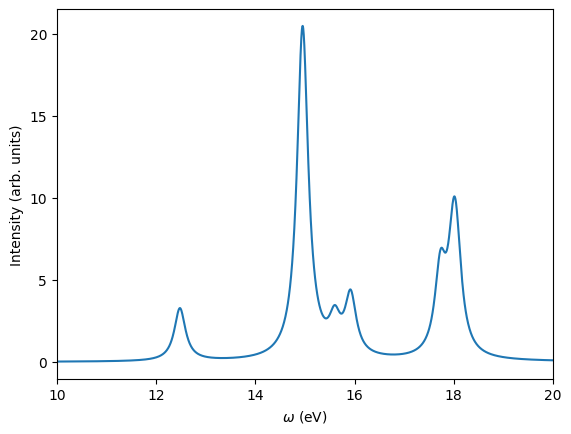

In [17]:
plt.plot(data[:,0]*27.211385, data[:,1])
plt.xlabel(r'$\omega$ (eV)')
plt.ylabel(r'Intensity (arb. units)')
plt.xlim([10,20])

# Challenge

<b>Compute optical spectrum of a molecule of your choice (not too big!). </b>
 - careful with pseudopotentials
 - update nbnd
 - update other settings you might be interested in (if in doubt, ask)